# 01 Data Understanding

This notebook inspects the five raw Olist CSV files needed for the delivery time prediction project. The goal is only to understand the raw tables individually before cleaning, merging, or feature engineering in later notebooks.

## Setup

Import the libraries needed for loading CSV files, displaying summaries, and creating simple exploratory plots.

In [4]:
from pathlib import Path  # Import Path to build file paths that work across operating systems.

import matplotlib.pyplot as plt  # Import pyplot to create charts for categorical counts and numeric distributions.
import pandas as pd  # Import pandas to load CSV files and inspect tabular data.

## Load Raw CSV Files

Load the five raw datasets from `../data/raw/` exactly as they are stored. No tables are merged, cleaned, or feature engineered in this notebook.

In [5]:
from pathlib import Path  # Import Path to build file paths that work across operating systems.

raw_data_dir = Path("../data/raw")  # Store the relative path to the raw data folder.

orders = pd.read_csv(raw_data_dir / "olist_orders_dataset.csv")  # Load the raw orders table.
order_items = pd.read_csv(raw_data_dir / "olist_order_items_dataset.csv")  # Load the raw order items table.
products = pd.read_csv(raw_data_dir / "olist_products_dataset.csv")  # Load the raw products table.
sellers = pd.read_csv(raw_data_dir / "olist_sellers_dataset.csv")  # Load the raw sellers table.
customers = pd.read_csv(raw_data_dir / "olist_customers_dataset.csv")  # Load the raw customers table.

tables = {  # Create a dictionary so each raw table can be inspected one at a time.
    "orders": orders,  # Add the orders table to the inspection dictionary.
    "order_items": order_items,  # Add the order items table to the inspection dictionary.
    "products": products,  # Add the products table to the inspection dictionary.
    "sellers": sellers,  # Add the sellers table to the inspection dictionary.
    "customers": customers,  # Add the customers table to the inspection dictionary.
}  # Close the dictionary of raw tables.

## Helper Function for Individual Table Inspection

Define a small display helper so each raw table is inspected with the same checks: shape, column data types, missing value counts, duplicate row count, and the first three rows.

In [6]:
def inspect_table(table_name, table_df):  # Define a helper that prints and displays one table summary at a time.
    print(f"{table_name.upper()} TABLE")  # Print the table name as a section label.
    print(f"Shape: {table_df.shape}")  # Print the number of rows and columns in the table.
    print("\nColumn dtypes:")  # Print a heading for the column data types.
    display(table_df.dtypes.to_frame(name="dtype"))  # Display each column name with its pandas data type.
    print("\nMissing value counts:")  # Print a heading for missing values by column.
    display(table_df.isna().sum().to_frame(name="missing_count"))  # Display the count of missing values in each column.
    duplicate_count = table_df.duplicated().sum()  # Count rows that are exact duplicates across all columns.
    print(f"\nDuplicate row count: {duplicate_count}")  # Print the exact duplicate row count.
    print("\nFirst 3 rows:")  # Print a heading before previewing the first rows.
    display(table_df.head(3))  # Display the first three rows of the table.
    print("-" * 80)  # Print a divider to separate this table from the next one.

## Inspect Orders Table

Inspect the raw orders table individually, without joining it to any other table.

In [7]:
inspect_table("orders", orders)  # Show shape, dtypes, missing counts, duplicate count, and first rows for orders.

ORDERS TABLE
Shape: (99441, 8)

Column dtypes:


,dtype
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,object
order_approved_at,object
order_delivered_carrier_date,object
order_delivered_customer_date,object
order_estimated_delivery_date,object



Missing value counts:


,missing_count
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0



Duplicate row count: 0

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


--------------------------------------------------------------------------------


## Inspect Order Items Table

Inspect the raw order items table individually, without joining it to any other table.

In [8]:
inspect_table("order_items", order_items)  # Show shape, dtypes, missing counts, duplicate count, and first rows for order items.

ORDER_ITEMS TABLE
Shape: (112650, 7)

Column dtypes:


,dtype
order_id,object
order_item_id,int64
product_id,object
seller_id,object
shipping_limit_date,object
price,float64
freight_value,float64



Missing value counts:


,missing_count
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0



Duplicate row count: 0

First 3 rows:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


--------------------------------------------------------------------------------


## Inspect Products Table

Inspect the raw products table individually, without joining it to any other table.

In [9]:
inspect_table("products", products)  # Show shape, dtypes, missing counts, duplicate count, and first rows for products.

PRODUCTS TABLE
Shape: (32951, 9)

Column dtypes:


,dtype
product_id,object
product_category_name,object
product_name_lenght,float64
product_description_lenght,float64
product_photos_qty,float64
product_weight_g,float64
product_length_cm,float64
product_height_cm,float64
product_width_cm,float64



Missing value counts:


,missing_count
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2



Duplicate row count: 0

First 3 rows:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


--------------------------------------------------------------------------------


## Inspect Sellers Table

Inspect the raw sellers table individually, without joining it to any other table.

In [10]:
inspect_table("sellers", sellers)  # Show shape, dtypes, missing counts, duplicate count, and first rows for sellers.

SELLERS TABLE
Shape: (3095, 4)

Column dtypes:


,dtype
seller_id,object
seller_zip_code_prefix,int64
seller_city,object
seller_state,object



Missing value counts:


,missing_count
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0



Duplicate row count: 0

First 3 rows:


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


--------------------------------------------------------------------------------


## Inspect Customers Table

Inspect the raw customers table individually, without joining it to any other table.

In [11]:
inspect_table("customers", customers)  # Show shape, dtypes, missing counts, duplicate count, and first rows for customers.

CUSTOMERS TABLE
Shape: (99441, 5)

Column dtypes:


,dtype
customer_id,object
customer_unique_id,object
customer_zip_code_prefix,int64
customer_city,object
customer_state,object



Missing value counts:


,missing_count
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0



Duplicate row count: 0

First 3 rows:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


--------------------------------------------------------------------------------


## Order Status Distribution

Check the frequency of each `order_status` value in the raw orders table. This helps identify how many orders are delivered versus canceled, unavailable, or still in other workflow states.

,order_count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


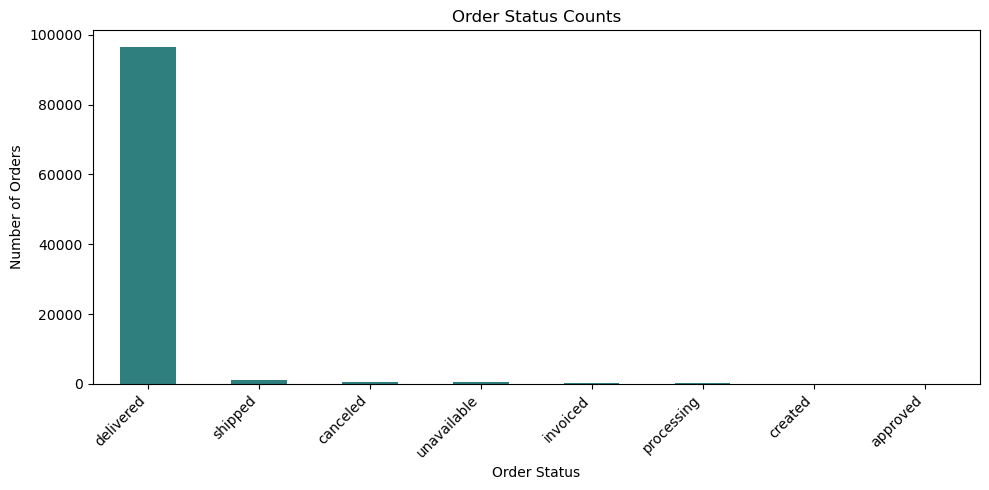

Percentage of orders with status 'delivered': 97.02%


In [12]:
order_status_counts = orders["order_status"].value_counts()  # Count how many orders appear in each order status category.

display(order_status_counts.to_frame(name="order_count"))  # Display the order status counts as a one-column table.

ax = order_status_counts.plot(kind="bar", figsize=(10, 5), color="#2f7f7f")  # Plot order status counts as a bar chart.
ax.set_title("Order Status Counts")  # Add a descriptive chart title.
ax.set_xlabel("Order Status")  # Label the x-axis with the category name.
ax.set_ylabel("Number of Orders")  # Label the y-axis with the count measure.
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels so they are easier to read.
plt.tight_layout()  # Adjust spacing so labels and titles fit cleanly.
plt.show()  # Display the completed bar chart.

delivered_percentage = (orders["order_status"].eq("delivered").mean()) * 100  # Calculate the percentage of orders marked as delivered.
print(f"Percentage of orders with status 'delivered': {delivered_percentage:.2f}%")  # Print the delivered percentage rounded to two decimals.

## Price and Freight Value Distributions

Plot histograms for the raw `price` and `freight_value` columns from the order items table. These plots show the spread and skew of monetary values before any cleaning or transformation.

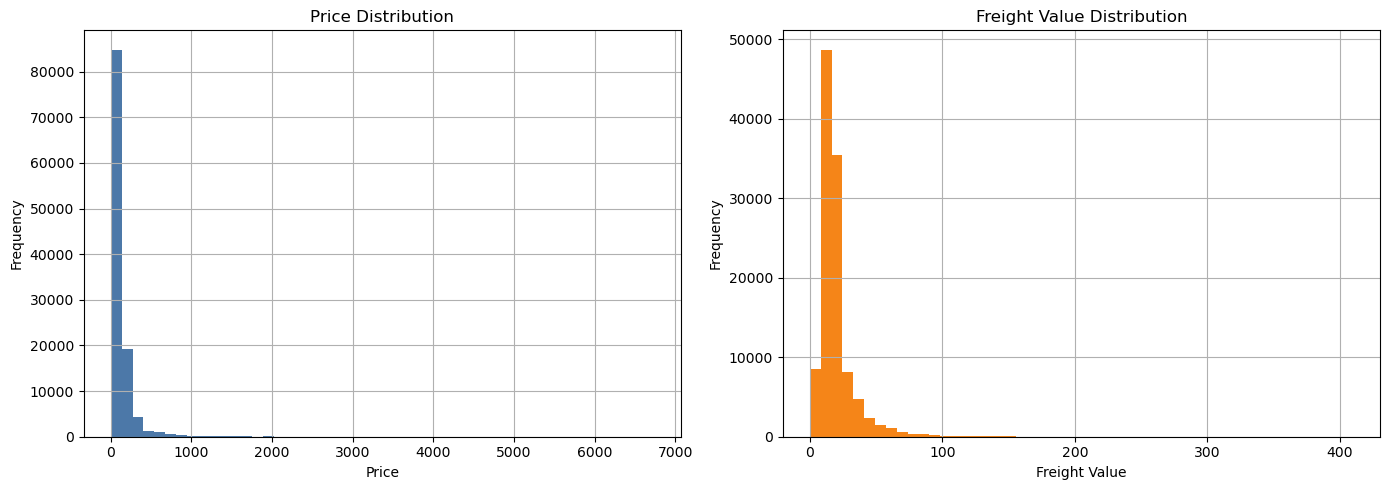

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # Create one row with two chart areas for the two histograms.

order_items["price"].hist(bins=50, ax=axes[0], color="#4c78a8")  # Plot a histogram of item prices using 50 bins.
axes[0].set_title("Price Distribution")  # Add a title to the price histogram.
axes[0].set_xlabel("Price")  # Label the x-axis with the price variable name.
axes[0].set_ylabel("Frequency")  # Label the y-axis with the number of rows per bin.

order_items["freight_value"].hist(bins=50, ax=axes[1], color="#f58518")  # Plot a histogram of freight values using 50 bins.
axes[1].set_title("Freight Value Distribution")  # Add a title to the freight value histogram.
axes[1].set_xlabel("Freight Value")  # Label the x-axis with the freight value variable name.
axes[1].set_ylabel("Frequency")  # Label the y-axis with the number of rows per bin.

plt.tight_layout()  # Adjust spacing so the two histograms fit cleanly.
plt.show()  # Display the completed histogram figure.

## Total Missing Values by Table

Compare the total number of missing values in each raw table. This gives a high-level view of which tables will need the most cleaning attention later.

,total_missing_values
orders,4908
order_items,0
products,2448
sellers,0
customers,0


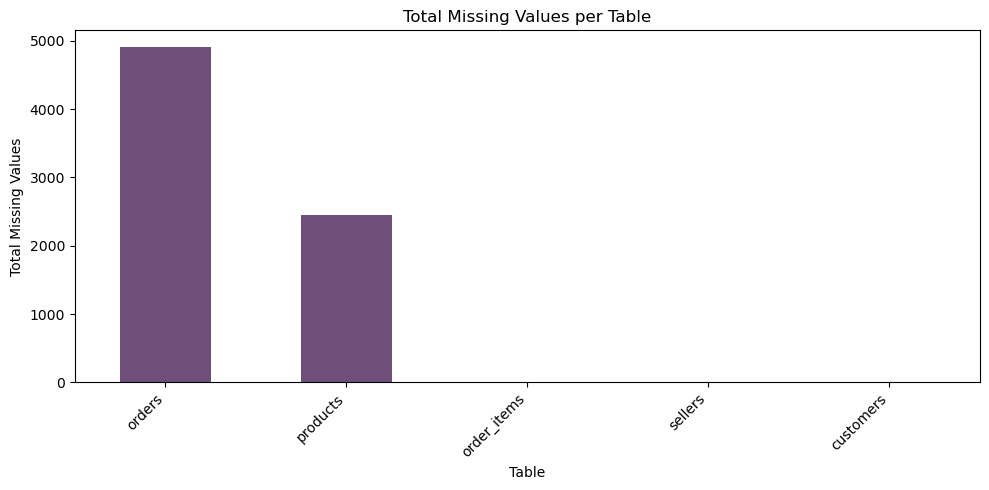

In [14]:
missing_totals = pd.Series({name: df.isna().sum().sum() for name, df in tables.items()})  # Calculate total missing values for each raw table.

display(missing_totals.to_frame(name="total_missing_values"))  # Display total missing values per table as a summary table.

ax = missing_totals.sort_values(ascending=False).plot(kind="bar", figsize=(10, 5), color="#6f4e7c")  # Plot total missing values per table in descending order.
ax.set_title("Total Missing Values per Table")  # Add a descriptive chart title.
ax.set_xlabel("Table")  # Label the x-axis with table names.
ax.set_ylabel("Total Missing Values")  # Label the y-axis with the total missing value count.
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels so table names are readable.
plt.tight_layout()  # Adjust chart spacing so labels are not cut off.
plt.show()  # Display the completed bar chart.

## Key Observations for Later Cleaning

- The orders table contains several timestamp columns loaded as object/string values, so later cleaning should convert them to datetime before calculating delivery durations.
- Not every order is marked as `delivered`, so later modeling work should decide whether to keep only delivered orders when the target depends on actual delivery dates.
- Missing values are concentrated in specific columns and tables, especially product attributes and some order date fields, so cleaning should handle missingness column by column rather than dropping rows blindly.
- The `price` and `freight_value` distributions are right-skewed, so later analysis should check extreme values before choosing transformations or model inputs.